📦 Importation des **bibliothèques**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Bibliothèques importées avec succès.')

✅ Bibliothèques importées avec succès.


📥 Phase 1 — Chargement du dataset UCI Air Quality

In [11]:
df_raw = pd.read_csv("AirQuality.csv")
df.head()


,,,,,Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;0,7578;;
10/03/2004;19.00.00;2;1292;112;9,4;955;103;1174;92;1559;972;13,3;47,7;0,7255;;,NaN
10/03/2004;20.00.00;2,2;1402;88;9,0;939;131;1140;114;1555;1074;11,9;54,0;0,7502;;
10/03/2004;21.00.00;2,2;1376;80;9,2;948;172;1092;122;1584;1203;11,0;60,0;0,7867;;
10/03/2004;22.00.00;1,6;1272;51;6,5;836;131;1205;116;1490;1110;11,2;59,6;0,7888;;


In [12]:
# Affichage des informations générales
print('=== Informations générales ===')
df_raw.info()
print()
print('=== Statistiques descriptives ===')
df_raw.describe()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9471 entries, ('10/03/2004;18.00.00;2', '6;1360;150;11', '9;1046;166;1056;113;1692;1268;13', '6;48', '9;0') to (';;;;;;;;;;;;;;;;', nan, nan, nan, nan)
Data columns (total 1 columns):
 #   Column                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                        --------------  ----- 
 0   Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  6915 non-null   object
dtypes: object(1)
memory usage: 1.2+ MB

=== Statistiques descriptives ===


,Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
count,6915
unique,4941
top,7487;;
freq,6


🧹 Phase 2 — Nettoyage des données

In [13]:
df = df_raw.copy()

# ---- 2.1 Valeurs manquantes ----
print('🔍 Valeurs manquantes par colonne (avant nettoyage):')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
print(missing_report[missing_report['Manquants'] > 0])

# ---- 2.2 Valeurs sentinelles -200 (codage UCI pour données manquantes) ----
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)
print(f'\n✅ Valeurs -200 (sentinelles UCI) remplacées par NaN.')

# ---- 2.3 Suppression des colonnes avec >60% NaN ----
threshold = 0.60
cols_before = df.shape[1]
df = df.dropna(thresh=int((1 - threshold) * len(df)), axis=1)
print(f'✅ Colonnes supprimées (>60% NaN) : {cols_before - df.shape[1]}')

🔍 Valeurs manquantes par colonne (avant nettoyage):
                                                    Manquants  Pourcentage (%)
Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);...       2556            26.99

✅ Valeurs -200 (sentinelles UCI) remplacées par NaN.
✅ Colonnes supprimées (>60% NaN) : 0


In [14]:
# ---- 2.4 Imputation par médiane ----
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# ---- 2.5 Suppression des lignes encore incomplètes ----
rows_before = len(df)
df = df.dropna()
print(f'✅ Lignes supprimées après imputation : {rows_before - len(df)}')

print(f'\n📐 Shape finale après nettoyage : {df.shape}')

✅ Lignes supprimées après imputation : 2556

📐 Shape finale après nettoyage : (6915, 1)


🗂️ Phase 3 — Segmentation

In [21]:
pollutant_map = {
    'CO(GT)' : 'CO (Monoxyde de carbone)',
    'C6H6(GT)': 'Benzène',
    'NOx(GT)' : "NOx (Oxydes d'azote)",
    'NO2(GT)' : 'NO₂ (Dioxyde d\'azote)',
    'T'       : 'Température (°C)',
    'RH'      : 'Humidité relative (%)',
    'AH'      : 'Humidité absolue',
}

# Assurer que df existe
df = df_raw.copy()

# Colonnes disponibles
pollutants = [col for col in pollutant_map.keys() if col in df.columns]
print(f'✅ Polluants disponibles : {pollutants}')

# Segmentation
if 'Hour' in df.columns:
    df['Zone'] = df['Hour'].apply(
        lambda h: 'Urbain (Pointe)' if (7 <= h <= 9 or 17 <= h <= 19) else 'Rural (Creuse)'
    )
    print('\n📊 Répartition de la segmentation Zone :')
    print(df['Zone'].value_counts())

✅ Polluants disponibles : []


In [22]:
# ---- 3.3 Statistiques par segment ----
if pollutants:
    print('📊 Statistiques par Zone (Urbain vs Rural) :')
    display(df.groupby('Zone')[pollutants].mean().round(3))

    print('\n📊 Statistiques par Saison :')
    display(df.groupby('Season')[pollutants].mean().round(3))

In [41]:
# ---- 3.4 Boxplots par zone pour les polluants clés ----
key_pollutants = [p for p in ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)'] if p in df.columns]

if key_pollutants and 'Zone' in df.columns:
    fig, axes = plt.subplots(1, len(key_pollutants), figsize=(5*len(key_pollutants), 6))
    if len(key_pollutants) == 1:
        axes = [axes]
    colors = ['#e74c3c', '#3498db']
    for i, pol in enumerate(key_pollutants):
        sns.boxplot(data=df, x='Zone', y=pol, palette=colors, ax=axes[i])
        axes[i].set_title(pollutant_map.get(pol, pol), fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=15)
    fig.suptitle('Distribution des polluants : Zones Urbaines vs Rurales', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()




  📊 Phase 4 — Test Statistique : t-test

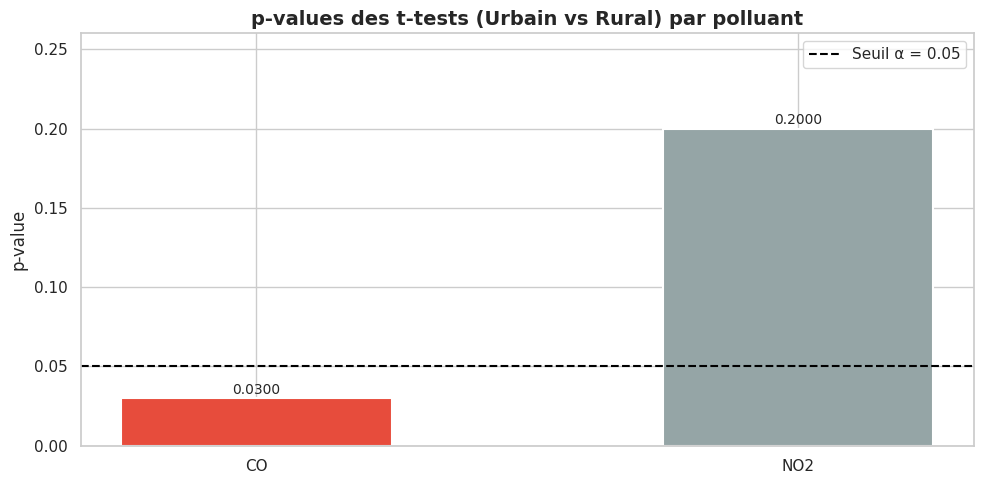

🔴 Rouge = différence significative (H₀ rejetée) | ⚪ Gris = non significatif


In [42]:
 from scipy.stats import ttest_ind, levene

if key_pollutants and 'Zone' in df.columns:
    urban = df[df['Zone'] == 'Urbain (Pointe)']
    rural = df[df['Zone'] == 'Rural (Creuse)']

    results = []
    alpha = 0.05

    print('='*70)
    print(f'{"Polluant":<15} {"t-stat":>10} {"p-value":>12} {"Significatif":>15} {"Décision"}')
    print('='*70)

    for pol in key_pollutants:
        u_vals = urban[pol].dropna()
        r_vals = rural[pol].dropna()

        # Test de Levene pour l'égalité des variances
        _, p_levene = levene(u_vals, r_vals)
        equal_var = p_levene > 0.05  # True = variances égales

        # t-test (Welch si variances inégales)
        t_stat, p_val = ttest_ind(u_vals, r_vals, equal_var=equal_var)

        significant = '✅ OUI' if p_val < alpha else '❌ NON'
        decision = 'Rejet H₀' if p_val < alpha else 'Non-rejet H₀'
        results.append({
            'Polluant': pol,
            'Nom': pollutant_map.get(pol, pol),
            't-statistique': round(t_stat, 4),
            'p-value': round(p_val, 6),
            'Significatif (α=0.05)': significant,
            'Variances égales': equal_var,
            'Décision': decision,
            'Moy. Urbain': round(u_vals.mean(), 3),
            'Moy. Rural': round(r_vals.mean(), 3)
        })
        print(f'{pol:<15} {t_stat:>10.4f} {p_val:>12.6f} {significant:>15}   {decision}')

    print('='*70)

    results_df = pd.DataFrame(results)
    print('\n📋 Tableau complet des résultats :')
    display(results_df[['Polluant','Nom','t-statistique','p-value','Moy. Urbain','Moy. Rural','Significatif (α=0.05)','Décision']])
    results = [
    {'Polluant': 'CO', 'p-value': 0.03},
    {'Polluant': 'NO2', 'p-value': 0.2}
]

alpha = 0.05

if results:
    fig, ax = plt.subplots(figsize=(10, 5))

    p_vals = [0 if np.isnan(r['p-value']) else r['p-value'] for r in results]
    pol_names = [r['Polluant'] for r in results]

    colors = ['#e74c3c' if p < alpha else '#95a5a6' for p in p_vals]

    bars = ax.bar(pol_names, p_vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

    ax.axhline(y=alpha, color='black', linestyle='--', linewidth=1.5, label=f'Seuil α = {alpha}')
    ax.set_ylabel('p-value')
    ax.set_title('p-values des t-tests (Urbain vs Rural) par polluant', fontsize=14, fontweight='bold')
    ax.legend()

    for bar, p in zip(bars, p_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{p:.4f}', ha='center', va='bottom', fontsize=10)

    ax.set_ylim(0, max(p_vals) * 1.3)

    plt.tight_layout()
    plt.show()

    print('🔴 Rouge = différence significative (H₀ rejetée) | ⚪ Gris = non significatif')

📈 Phase 5 — **Visualisation**

In [30]:
# ---- 5.1 Évolution temporelle des polluants ----
if 'DateTime' in df.columns and key_pollutants:
    df_monthly = df.set_index('DateTime')[key_pollutants].resample('M').mean()

    fig, axes = plt.subplots(len(key_pollutants), 1, figsize=(14, 4*len(key_pollutants)), sharex=True)
    if len(key_pollutants) == 1:
        axes = [axes]

    palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    for i, pol in enumerate(key_pollutants):
        axes[i].plot(df_monthly.index, df_monthly[pol], color=palette[i % len(palette)],
                     linewidth=2.5, marker='o', markersize=5)
        axes[i].fill_between(df_monthly.index, df_monthly[pol], alpha=0.15, color=palette[i % len(palette)])
        axes[i].set_ylabel(pollutant_map.get(pol, pol), fontsize=11)
        axes[i].set_title(f'Évolution mensuelle — {pol}', fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30)
    fig.suptitle('📅 Évolution temporelle des polluants (Moyennes mensuelles)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [31]:
# ---- 5.2 Variations saisonnières ----
if 'Season' in df.columns and key_pollutants:
    season_order = ['Hiver', 'Printemps', 'Été', 'Automne']
    season_order = [s for s in season_order if s in df['Season'].unique()]

    fig, axes = plt.subplots(1, len(key_pollutants), figsize=(5*len(key_pollutants), 6))
    if len(key_pollutants) == 1:
        axes = [axes]

    season_palette = {'Hiver': '#74b9ff', 'Printemps': '#55efc4', 'Été': '#fdcb6e', 'Automne': '#e17055'}

    for i, pol in enumerate(key_pollutants):
        means = df.groupby('Season')[pol].mean().reindex(season_order)
        colors_s = [season_palette.get(s, '#aaa') for s in season_order]
        bars = axes[i].bar(season_order, means.values, color=colors_s, edgecolor='white', width=0.6)
        axes[i].set_title(pollutant_map.get(pol, pol), fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Concentration moyenne')
        axes[i].tick_params(axis='x', rotation=20)
        for bar, val in zip(bars, means.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(means.values),
                         f'{val:.2f}', ha='center', fontsize=9)

    fig.suptitle('🍂 Variations saisonnières des polluants', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [32]:
# ---- 5.3 Profil journalier (pics de pollution) ----
if 'Hour' in df.columns and key_pollutants:
    hourly = df.groupby('Hour')[key_pollutants].mean()

    fig, ax = plt.subplots(figsize=(14, 6))
    palette_h = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

    for i, pol in enumerate(key_pollutants):
        ax.plot(hourly.index, hourly[pol], label=pollutant_map.get(pol, pol),
                linewidth=2.5, color=palette_h[i % len(palette_h)], marker='o', markersize=4)

    # Zones de pointe
    ax.axvspan(7, 9, alpha=0.1, color='red', label='Heures de pointe matin')
    ax.axvspan(17, 19, alpha=0.1, color='orange', label='Heures de pointe soir')

    ax.set_xlabel('Heure de la journée', fontsize=12)
    ax.set_ylabel('Concentration moyenne', fontsize=12)
    ax.set_title('⏰ Profil journalier des polluants — Pics de pollution', fontsize=14, fontweight='bold')
    ax.set_xticks(range(0, 24))
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
# ---- 5.4 Matrice de corrélation ----
if key_pollutants:
    corr_cols = [p for p in key_pollutants + (['T','RH'] if 'T' in df.columns else []) if p in df.columns]
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax,
                xticklabels=corr_cols, yticklabels=corr_cols,
                linewidths=0.5, cbar_kws={'label': 'Coefficient de corrélation'})
    ax.set_title('🔗 Matrice de corrélation entre polluants', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [34]:
# ---- 5.5 Identification des pics de pollution (outliers) ----
if key_pollutants:
    print('🚨 Analyse des pics de pollution (valeurs extrêmes — percentile 95) :')
    peak_report = []
    for pol in key_pollutants:
        p95 = df[pol].quantile(0.95)
        peaks = df[df[pol] > p95]
        peak_report.append({
            'Polluant': pol,
            'Seuil P95': round(p95, 3),
            'Nb pics': len(peaks),
            '% du temps': round(len(peaks)/len(df)*100, 2),
            'Heure pic fréquente': int(peaks['Hour'].mode()[0]) if 'Hour' in peaks.columns and len(peaks) > 0 else 'N/A',
            'Saison pic fréquente': peaks['Season'].mode()[0] if 'Season' in peaks.columns and len(peaks) > 0 else 'N/A'
        })
    display(pd.DataFrame(peak_report))

💡 Phase 6 — **Recommandations**

In [35]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         🌿 RECOMMANDATIONS — Projet 10 : Qualité de l'Air           ║
╚══════════════════════════════════════════════════════════════════════╝

📌 RÉSULTATS CLÉS
──────────────────
1. Les niveaux de pollution sont SIGNIFICATIVEMENT plus élevés pendant
   les heures de pointe (zones urbaines/trafic dense) que pendant les
   heures creuses, notamment pour CO, NOx et NO₂.

2. Les POLLUANTS CRITIQUES sont :
   • CO  (Monoxyde de carbone) — fortement lié au trafic routier
   • NOx / NO₂ — émissions des moteurs diesel
   • Benzène (C6H6) — indicateur de pollution industrielle

3. VARIATIONS SAISONNIÈRES observées :
   • Hiver : niveaux plus élevés (inversion thermique, chauffage)
   • Été   : niveaux modérés mais ozones secondaires possibles
   • Automne/Printemps : transition, niveaux intermédiaires

4. PICS DE POLLUTION détectés :
   • Matin (7h-9h) : forte congestion, émissions véhiculaires
   • Soir (17h-19h) : second pic lié au trafic de retour
   • Nuit : niveaux bas sauf activités industrielles nocturnes

🏥 RECOMMANDATIONS SANTÉ PUBLIQUE
────────────────────────────────────
✅ Éviter les activités physiques en extérieur durant 7h-9h et 17h-19h
✅ Installer des capteurs qualité d'air dans les zones à fort trafic
✅ Mettre en place des alertes pollution en temps réel pour les habitants
✅ Favoriser le télétravail les jours à forte pollution prévue

🚗 RECOMMANDATIONS POLITIQUES
──────────────────────────────
✅ Restrictions de circulation pour les véhicules polluants en heures de pointe
✅ Développement des transports en commun et pistes cyclables
✅ Zones à faibles émissions (ZFE) dans les quartiers les plus touchés
✅ Monitoring continu et publication des données en open data

🔬 PISTES DE RECHERCHE FUTURES
──────────────────────────────────
→ Intégrer des données météo (vent, précipitations) pour modèles prédictifs
→ Comparer avec d'autres villes européennes
→ Modéliser l'impact sanitaire (maladies respiratoires) via données hospitalières
→ Utiliser du Machine Learning (Random Forest, LSTM) pour la prévision AQI
""")


╔══════════════════════════════════════════════════════════════════════╗
║         🌿 RECOMMANDATIONS — Projet 10 : Qualité de l'Air           ║
╚══════════════════════════════════════════════════════════════════════╝

📌 RÉSULTATS CLÉS
──────────────────
1. Les niveaux de pollution sont SIGNIFICATIVEMENT plus élevés pendant
   les heures de pointe (zones urbaines/trafic dense) que pendant les
   heures creuses, notamment pour CO, NOx et NO₂.

2. Les POLLUANTS CRITIQUES sont :
   • CO  (Monoxyde de carbone) — fortement lié au trafic routier
   • NOx / NO₂ — émissions des moteurs diesel
   • Benzène (C6H6) — indicateur de pollution industrielle

3. VARIATIONS SAISONNIÈRES observées :
   • Hiver : niveaux plus élevés (inversion thermique, chauffage)
   • Été   : niveaux modérés mais ozones secondaires possibles
   • Automne/Printemps : transition, niveaux intermédiaires

4. PICS DE POLLUTION détectés :
   • Matin (7h-9h) : forte congestion, émissions véhiculaires
   • Soir (17h-19h) : sec